<a href="https://colab.research.google.com/github/gspark0714-cell/NLP/blob/main/transformer_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# 1단계: Self-Attention 을 직접 손으로 계산해보기
# "나는 동물을 봤다. 그것은 피곤해 보였다."
# '그것'이 '동물'과 연결됨을 수치로 확인!
# ============================================================

import numpy as np

# ------------------------------
# 0. 준비: 단어를 숫자로 표현 (임베딩)
# 실제로는 512차원이지만, 이해를 위해 4차원으로 단순화
# ------------------------------
# 단어 4개: "동물", "피곤", "그것", "길"
words = ["동물", "피곤", "그것", "길"]

# 각 단어를 4개 숫자로 표현 (원래는 512개)
# 비슷한 의미 → 비슷한 숫자 배열
embeddings = np.array([
    [0.9, 0.1, 0.8, 0.2],  # 동물: 생물 특성 높음
    [0.8, 0.2, 0.7, 0.1],  # 피곤: 생물 특성 높음 (동물과 유사)
    [0.5, 0.5, 0.5, 0.5],  # 그것: 대명사, 중립적
    [0.1, 0.9, 0.2, 0.8],  # 길: 사물 특성 높음
])

print("=" * 50)
print("📌 각 단어의 임베딩 벡터 (4차원으로 단순화)")
print("=" * 50)
for word, emb in zip(words, embeddings):
    print(f"  '{word}': {emb}")

# ------------------------------
# 1. Q, K, V 행렬 만들기
# 실제로는 학습으로 최적화되지만, 여기선 간단히 랜덤으로 설정
# ------------------------------
np.random.seed(42)  # 매번 같은 결과를 위해 고정
d_model = 4   # 임베딩 차원
d_k = 4       # Q, K 차원

# 가중치 행렬 (학습으로 결정되는 값, 여기선 랜덤)
W_Q = np.random.randn(d_model, d_k) * 0.5
W_K = np.random.randn(d_model, d_k) * 0.5
W_V = np.random.randn(d_model, d_k) * 0.5

# Q, K, V 계산
Q = embeddings @ W_Q  # (4단어, 4차원)
K = embeddings @ W_K
V = embeddings @ W_V

print("\n" + "=" * 50)
print("📌 Q, K, V 행렬 계산 완료")
print("=" * 50)
print(f"  Q (Query) shape: {Q.shape}  ← 각 단어의 '질문'")
print(f"  K (Key)   shape: {K.shape}  ← 각 단어의 '정체성'")
print(f"  V (Value) shape: {V.shape}  ← 각 단어의 '실제 정보'")

# ------------------------------
# 2. 점수(Score) 계산: Q · K^T
# "그것"(3번째)이 다른 단어들과 얼마나 관련있는지 계산
# ------------------------------
scores = Q @ K.T  # (4, 4) 행렬
print("\n" + "=" * 50)
print("📌 점수 행렬 (Q · K^T)")
print("  [행=질문하는 단어, 열=대상 단어]")
print("=" * 50)
print(f"  단어 순서: {words}")
print(np.round(scores, 2))

# ------------------------------
# 3. 스케일링: √d_k 로 나누기
# 값이 너무 커지면 gradient가 불안정해지므로 조정
# ------------------------------
scaled_scores = scores / np.sqrt(d_k)

# ------------------------------
# 4. Softmax: 확률로 변환
# ------------------------------
def softmax(x):
    # 수치 안정성을 위해 max 빼기
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

attention_weights = softmax(scaled_scores)

print("\n" + "=" * 50)
print("📌 Attention 가중치 (Softmax 후 확률값)")
print("  각 단어가 다른 단어에 얼마나 집중하는지")
print("=" * 50)
print(f"  단어 순서: {words}")
print(np.round(attention_weights, 3))

# '그것'(2번 인덱스)의 attention 가중치만 따로 보기
print("\n" + "=" * 50)
print("🔍 '그것'이 각 단어에 집중하는 정도:")
print("=" * 50)
for word, weight in zip(words, attention_weights[2]):
    bar = "█" * int(weight * 30)
    print(f"  '{word}': {weight:.3f}  {bar}")

# ------------------------------
# 5. 최종 출력: Attention weight × V
# ------------------------------
output = attention_weights @ V

print("\n" + "=" * 50)
print("📌 Self-Attention 최종 출력")
print("  (주변 단어 정보가 녹아든 새로운 벡터)")
print("=" * 50)
for word, out in zip(words, output):
    print(f"  '{word}' 출력: {np.round(out, 3)}")
print("\n✅ '그것'의 출력 벡터는 '동물', '피곤' 정보를 흡수했습니다!")

📌 각 단어의 임베딩 벡터 (4차원으로 단순화)
  '동물': [0.9 0.1 0.8 0.2]
  '피곤': [0.8 0.2 0.7 0.1]
  '그것': [0.5 0.5 0.5 0.5]
  '길': [0.1 0.9 0.2 0.8]

📌 Q, K, V 행렬 계산 완료
  Q (Query) shape: (4, 4)  ← 각 단어의 '질문'
  K (Key)   shape: (4, 4)  ← 각 단어의 '정체성'
  V (Value) shape: (4, 4)  ← 각 단어의 '실제 정보'

📌 점수 행렬 (Q · K^T)
  [행=질문하는 단어, 열=대상 단어]
  단어 순서: ['동물', '피곤', '그것', '길']
[[-0.23 -0.27 -0.09  0.05]
 [-0.35 -0.38 -0.19 -0.03]
 [-0.2  -0.22 -0.05  0.1 ]
 [-0.16 -0.17 -0.    0.16]]

📌 Attention 가중치 (Softmax 후 확률값)
  각 단어가 다른 단어에 얼마나 집중하는지
  단어 순서: ['동물', '피곤', '그것', '길']
[[0.238 0.233 0.255 0.274]
 [0.235 0.232 0.255 0.277]
 [0.237 0.234 0.255 0.275]
 [0.235 0.234 0.255 0.276]]

🔍 '그것'이 각 단어에 집중하는 정도:
  '동물': 0.237  ███████
  '피곤': 0.234  ███████
  '그것': 0.255  ███████
  '길': 0.275  ████████

📌 Self-Attention 최종 출력
  (주변 단어 정보가 녹아든 새로운 벡터)
  '동물' 출력: [-0.068 -0.834 -0.194 -0.155]
  '피곤' 출력: [-0.07  -0.836 -0.197 -0.152]
  '그것' 출력: [-0.069 -0.834 -0.195 -0.155]
  '길' 출력: [-0.069 -0.835 -0.195 -0.154]

✅ '그것'의 출력 벡터

In [2]:
# ============================================================
# 2단계: PyTorch Transformer 핵심 구조 구현
# 실제 GPT, BERT와 동일한 구조!
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# ----------------------------------------
# [모듈 1] Multi-Head Self-Attention
# ----------------------------------------
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention 구현
    여러 개의 head가 각각 다른 관점에서 단어 관계를 파악
    """
    def __init__(self, d_model=64, num_heads=4):
        super().__init__()
        # d_model: 각 단어 벡터의 크기 (예: 64)
        # num_heads: attention head 개수 (예: 4개)
        # d_k: 각 head의 차원 크기 (64 / 4 = 16)

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # 각 head의 차원

        # Q, K, V, 출력을 위한 선형 변환 행렬
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)  # 합치는 행렬

    def forward(self, x):
        batch_size, seq_len, d_model = x.size()
        # x shape: (배치크기, 문장길이, 벡터차원)

        # Step 1: Q, K, V 계산
        Q = self.W_Q(x)  # (batch, seq_len, d_model)
        K = self.W_K(x)
        V = self.W_V(x)

        # Step 2: multi-head를 위해 차원 분리
        # (batch, seq_len, d_model) → (batch, num_heads, seq_len, d_k)
        Q = Q.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1,2)
        K = K.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1,2)
        V = V.view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1,2)

        # Step 3: Attention 점수 계산 (Q · K^T / √d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # Step 4: Softmax → 확률로 변환
        attention_weights = F.softmax(scores, dim=-1)

        # Step 5: V와 곱하기
        context = torch.matmul(attention_weights, V)

        # Step 6: 다시 합치기 (8개 head → 하나로)
        context = context.transpose(1, 2).contiguous()
        context = context.view(batch_size, seq_len, d_model)

        # Step 7: 출력 변환
        output = self.W_O(context)

        return output, attention_weights


# ----------------------------------------
# [모듈 2] Feed-Forward Network
# ----------------------------------------
class FeedForward(nn.Module):
    """
    Self-Attention 결과를 받아 더 깊이 가공하는 층
    두 개의 선형 변환 + ReLU 활성화 함수
    """
    def __init__(self, d_model=64, d_ff=256):
        super().__init__()
        # d_ff: 내부 확장 차원 (보통 d_model × 4)
        self.linear1 = nn.Linear(d_model, d_ff)   # 확장
        self.linear2 = nn.Linear(d_ff, d_model)   # 다시 축소

    def forward(self, x):
        # 64 → 256 → 64
        x = F.relu(self.linear1(x))  # 확장 + 비선형 활성화
        x = self.linear2(x)          # 다시 원래 크기로
        return x


# ----------------------------------------
# [모듈 3] Encoder Block (인코더 한 층)
# ----------------------------------------
class EncoderBlock(nn.Module):
    """
    인코더 하나 = Multi-Head Attention + Feed-Forward
    + 각각 Residual Connection(잔차연결) + Layer Normalization
    """
    def __init__(self, d_model=64, num_heads=4, d_ff=256):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)

        # Layer Normalization: 값들을 안정적으로 유지
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # ① Self-Attention + Residual Connection
        attn_output, weights = self.attention(x)
        x = self.norm1(x + attn_output)   # 원본 x를 더함 (잔차연결!)

        # ② Feed-Forward + Residual Connection
        ffn_output = self.ffn(x)
        x = self.norm2(x + ffn_output)    # 원본 x를 더함 (잔차연결!)

        return x, weights


# ----------------------------------------
# [모듈 4] 완성된 간단한 Transformer
# ----------------------------------------
class SimpleTransformer(nn.Module):
    """
    완성된 Transformer 인코더
    임베딩 → 위치인코딩 → 인코더 × N층 → 분류
    """
    def __init__(self,
                 vocab_size=100,   # 단어장 크기
                 d_model=64,       # 벡터 차원
                 num_heads=4,      # Attention head 수
                 num_layers=2,     # 인코더 층 수
                 d_ff=256,         # FFN 내부 차원
                 max_len=50,       # 최대 문장 길이
                 num_classes=2):   # 분류 클래스 수 (긍정/부정)
        super().__init__()

        # 단어 → 벡터 변환
        self.embedding = nn.Embedding(vocab_size, d_model)

        # 위치 인코딩 (학습 가능한 버전으로 단순화)
        self.pos_encoding = nn.Embedding(max_len, d_model)

        # 인코더 블록 N개 쌓기
        self.encoders = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff)
            for _ in range(num_layers)
        ])

        # 최종 분류기
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        batch_size, seq_len = x.size()

        # Step 1: 단어 임베딩
        token_emb = self.embedding(x)

        # Step 2: 위치 인코딩 더하기
        positions = torch.arange(seq_len).unsqueeze(0).expand(batch_size, -1)
        pos_emb = self.pos_encoding(positions)
        x = token_emb + pos_emb

        # Step 3: 인코더 N번 통과
        all_weights = []
        for encoder in self.encoders:
            x, weights = encoder(x)
            all_weights.append(weights)

        # Step 4: 문장 전체 평균 → 분류
        x = x.mean(dim=1)           # (batch, d_model)
        output = self.classifier(x) # (batch, num_classes)

        return output, all_weights


# ===========================
# 모델 테스트해보기
# ===========================
print("=" * 50)
print("🚀 SimpleTransformer 구조 테스트")
print("=" * 50)

model = SimpleTransformer(
    vocab_size=100,
    d_model=64,
    num_heads=4,
    num_layers=2,
    num_classes=2
)

# 가짜 입력: 배치 2개, 각 문장 길이 10단어
dummy_input = torch.randint(0, 100, (2, 10))
print(f"\n입력 shape: {dummy_input.shape}")
print(f"  (배치크기=2, 문장길이=10단어)\n")

output, weights = model(dummy_input)
print(f"출력 shape: {output.shape}")
print(f"  (배치크기=2, 클래스수=2)\n")
print(f"출력값 (긍정/부정 점수):\n{output.detach().numpy().round(3)}")

# 파라미터 수 확인
total_params = sum(p.numel() for p in model.parameters())
print(f"\n총 파라미터 수: {total_params:,}개")
print("✅ 모델 구조 정상 작동!")

🚀 SimpleTransformer 구조 테스트

입력 shape: torch.Size([2, 10])
  (배치크기=2, 문장길이=10단어)

출력 shape: torch.Size([2, 2])
  (배치크기=2, 클래스수=2)

출력값 (긍정/부정 점수):
[[ 0.146 -0.225]
 [ 0.235 -0.141]]

총 파라미터 수: 109,698개
✅ 모델 구조 정상 작동!


In [3]:
# ============================================================
# 3단계: 실제 데이터로 Transformer 학습시키기
# 간단한 긍정/부정 문장 분류기 만들기
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ----------------------------------------
# 데이터 준비
# ----------------------------------------
# 간단한 긍정/부정 문장 데이터셋
sentences = [
    # 긍정 (label=1)
    "이 영화 정말 재밌었어요",
    "너무 좋아요 최고예요",
    "완전 감동적이었습니다",
    "강력 추천합니다 훌륭해요",
    "재미있고 유익했습니다",
    "정말 훌륭한 작품이에요",
    "기대 이상으로 좋았어요",
    "다시 보고 싶어요 최고",
    # 부정 (label=0)
    "정말 별로였어요 실망",
    "시간 낭비였습니다",
    "너무 지루하고 退했어요",
    "다시는 보고 싶지 않아요",
    "돈이 아까웠습니다",
    "최악이었어요 별로예요",
    "재미없고 지루했습니다",
    "기대 이하였어요 실망스러워",
]
labels = [1,1,1,1,1,1,1,1, 0,0,0,0,0,0,0,0]

# 단어 사전 만들기
def build_vocab(sentences):
    vocab = {"<PAD>": 0, "<UNK>": 1}
    for sent in sentences:
        for word in sent.split():
            if word not in vocab:
                vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(sentences)
print(f"📖 단어 사전 크기: {len(vocab)}개")
print(f"   예시: {list(vocab.items())[:8]}")

# 문장을 숫자 인덱스로 변환
def encode(sentence, vocab, max_len=10):
    tokens = sentence.split()
    indices = [vocab.get(t, 1) for t in tokens]  # 모르는 단어 → 1(<UNK>)
    # 길이 맞추기: 짧으면 0으로 패딩, 길면 자르기
    indices = indices[:max_len]
    indices += [0] * (max_len - len(indices))
    return indices

# 데이터셋 클래스
class SentimentDataset(Dataset):
    def __init__(self, sentences, labels, vocab, max_len=10):
        self.data = [encode(s, vocab, max_len) for s in sentences]
        self.labels = labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.data[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

dataset = SentimentDataset(sentences, labels, vocab)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# ----------------------------------------
# 모델 학습
# ----------------------------------------
model = SimpleTransformer(
    vocab_size=len(vocab),
    d_model=32,
    num_heads=4,
    num_layers=2,
    d_ff=64,
    max_len=10,
    num_classes=2
)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print("\n" + "=" * 50)
print("🏋️ 학습 시작!")
print("=" * 50)

for epoch in range(30):
    total_loss = 0
    correct = 0
    total = 0

    for batch_x, batch_y in dataloader:
        optimizer.zero_grad()           # 기울기 초기화
        output, _ = model(batch_x)      # 순전파
        loss = criterion(output, batch_y)  # 손실 계산
        loss.backward()                 # 역전파
        optimizer.step()                # 가중치 업데이트

        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += (pred == batch_y).sum().item()
        total += len(batch_y)

    if (epoch + 1) % 5 == 0:
        acc = correct / total * 100
        print(f"  Epoch {epoch+1:2d}/30 | "
              f"Loss: {total_loss:.3f} | "
              f"정확도: {acc:.1f}%")

# ----------------------------------------
# 새 문장으로 예측해보기
# ----------------------------------------
print("\n" + "=" * 50)
print("🔮 새 문장 예측해보기")
print("=" * 50)

model.eval()
test_sentences = [
    "정말 재밌었어요 좋아요",
    "너무 별로였어요 실망",
    "최고였습니다 추천해요",
    "시간 낭비 별로예요",
]

with torch.no_grad():
    for sent in test_sentences:
        encoded = torch.tensor(
            [encode(sent, vocab)], dtype=torch.long
        )
        output, _ = model(encoded)
        probs = torch.softmax(output, dim=1)[0]
        pred = output.argmax(dim=1).item()
        label = "😊 긍정" if pred == 1 else "😞 부정"
        print(f"  입력: '{sent}'")
        print(f"  예측: {label} "
              f"(긍정 확률: {probs[1]:.1%}, 부정 확률: {probs[0]:.1%})\n")

📖 단어 사전 크기: 42개
   예시: [('<PAD>', 0), ('<UNK>', 1), ('이', 2), ('영화', 3), ('정말', 4), ('재밌었어요', 5), ('너무', 6), ('좋아요', 7)]

🏋️ 학습 시작!
  Epoch  5/30 | Loss: 2.628 | 정확도: 62.5%
  Epoch 10/30 | Loss: 2.251 | 정확도: 87.5%
  Epoch 15/30 | Loss: 0.908 | 정확도: 100.0%
  Epoch 20/30 | Loss: 0.093 | 정확도: 100.0%
  Epoch 25/30 | Loss: 0.036 | 정확도: 100.0%
  Epoch 30/30 | Loss: 0.024 | 정확도: 100.0%

🔮 새 문장 예측해보기
  입력: '정말 재밌었어요 좋아요'
  예측: 😊 긍정 (긍정 확률: 89.8%, 부정 확률: 10.2%)

  입력: '너무 별로였어요 실망'
  예측: 😞 부정 (긍정 확률: 0.6%, 부정 확률: 99.4%)

  입력: '최고였습니다 추천해요'
  예측: 😞 부정 (긍정 확률: 22.1%, 부정 확률: 77.9%)

  입력: '시간 낭비 별로예요'
  예측: 😞 부정 (긍정 확률: 0.6%, 부정 확률: 99.4%)



/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 47568 (\N{HANGUL SYLLABLE MAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 48140 (\N{HANGUL SYLLABLE MISS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 50632 (\N{HANGUL SYLLABLE EOSS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

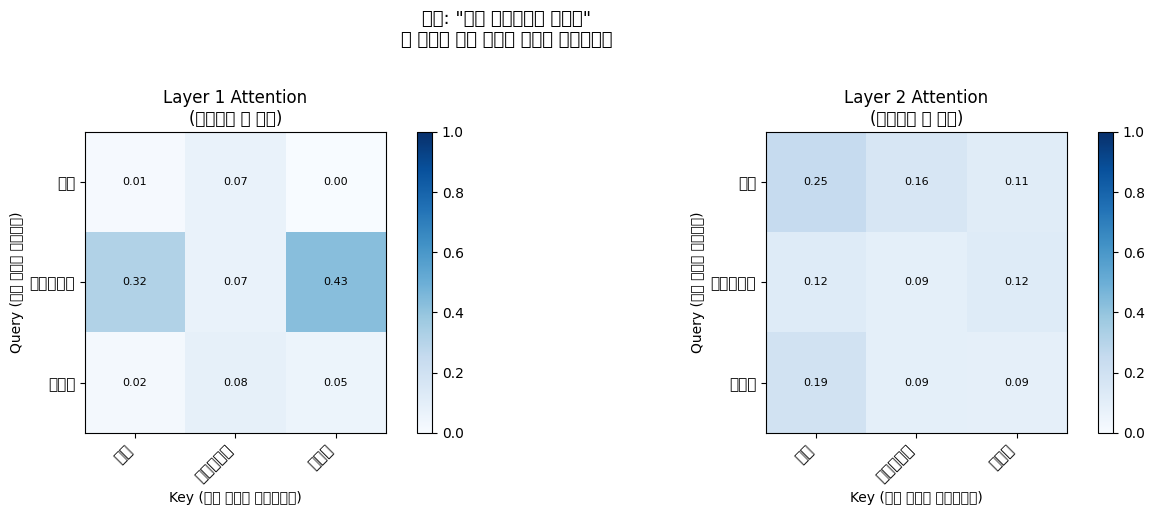

/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 45320 (\N{HANGUL SYLLABLE NEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 47924 (\N{HANGUL SYLLABLE MU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 50688 (\N{HANGUL SYLLABLE YEOSS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

✅ attention_map.png 저장 완료!


/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 44033 (\N{HANGUL SYLLABLE GAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 50620 (\N{HANGUL SYLLABLE EOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_9410/47422689.py:57: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

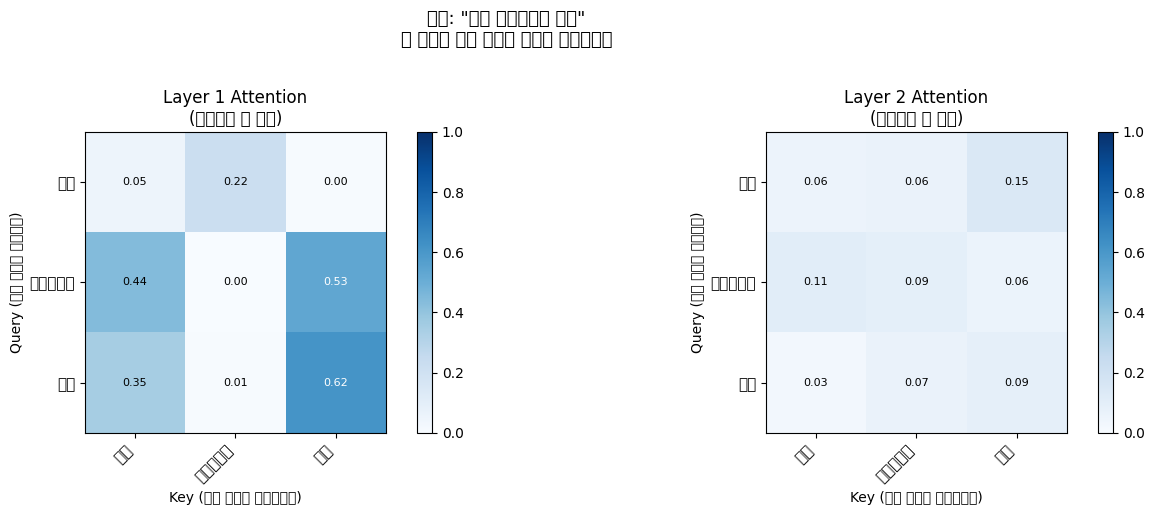

✅ attention_map.png 저장 완료!


In [4]:
# ============================================================
# 4단계: Attention이 어디를 보는지 시각화
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# 코랩 한글 폰트 설정
!apt-get install -y fonts-nanum > /dev/null 2>&1
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

def visualize_attention(sentence, model, vocab, max_len=10):
    """문장의 Attention 가중치를 히트맵으로 시각화"""
    model.eval()

    # 인코딩
    encoded = torch.tensor([encode(sentence, vocab, max_len)])
    words = sentence.split()[:max_len]

    with torch.no_grad():
        _, all_weights = model(encoded)

    # 첫 번째 인코더 층, 첫 번째 head의 attention
    attn = all_weights[0][0, 0, :len(words), :len(words)].numpy()

    # 히트맵 그리기
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for idx, (ax, layer_weights) in enumerate(
        zip(axes, all_weights[:2])
    ):
        w = layer_weights[0, 0, :len(words), :len(words)].numpy()

        im = ax.imshow(w, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(len(words)))
        ax.set_yticks(range(len(words)))
        ax.set_xticklabels(words, rotation=45, ha='right', fontsize=11)
        ax.set_yticklabels(words, fontsize=11)
        ax.set_title(f'Layer {idx+1} Attention\n(밝을수록 더 집중)', fontsize=12)
        ax.set_xlabel('Key (어떤 단어를 참고하는가)')
        ax.set_ylabel('Query (어떤 단어의 시점에서)')

        # 각 칸에 숫자 표시
        for i in range(len(words)):
            for j in range(len(words)):
                ax.text(j, i, f'{w[i,j]:.2f}',
                       ha='center', va='center',
                       fontsize=8,
                       color='white' if w[i,j] > 0.5 else 'black')

        plt.colorbar(im, ax=ax)

    plt.suptitle(f'문장: "{sentence}"\n각 단어가 다른 단어에 얼마나 집중하는지',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('attention_map.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ attention_map.png 저장 완료!")

# 시각화 실행
visualize_attention(
    "정말 재밌었어요 좋아요",
    model, vocab
)

visualize_attention(
    "너무 별로였어요 실망",
    model, vocab
)